## Problema
> O algorítimo irá aprender a predizer se um cidadão americano ganha mais ou menos que US$ 50 mil por ano segundo determinadas features (idade, escolaridade, sexo e etc). Para isso, foi utilizado a base de dados (dataset) adult disponível gratuitamente pelo repositório UCI.

> Dataset: https://www.kaggle.com/datasets/wenruliu/adult-income-dataset

In [1]:
# =================================================================
# 1. Bibliotecas e Configurações
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
# =================================================================
# 2. Carregamento dos Dados
# =================================================================
names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
         'marital-status', 'occupation', 'relationship', 'race', 'sex',
         'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
         'class']

url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSfy3DPYeTEjcnFhAQXoj8WzvsfyuGBQWl6U8rw9Qs9GzNpF4oC0C2oM3MxW52TpY3GOJfu63nJhpDV/pub?gid=538240197&single=true&output=csv'

# Carregar o dataset (tratando espaços em branco comuns neste dataset)
df = pd.read_csv(url, header=0, names=names, skipinitialspace=True)

In [3]:
# =================================================================
# 3. Pré-processamento
# =================================================================
# Substituir "?" por NaN e remover nulos (o dataset Adult usa "?" para dados faltantes)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Excluir as colunas que não serão utilizadas
df = df.drop(['fnlwgt', 'education-num'], axis=1)

# Transformar features categóricas em numéricas
non_numerical = names = ['age', 'workclass', 'education',
         'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

le = preprocessing.LabelEncoder()
for x in non_numerical:
    df[x] = le.fit_transform(df[x].astype(str))

# Separação das Features (X) e Label (y)
X = df.drop('class', axis=1).values
y = df['class'].values

# ESCALONAMENTO NORMALIZAÇÃO (Crucial para KNN): 
# Como o KNN usa distância, features com valores altos (como capital-gain)
# dominariam o modelo se não forem normalizadas.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
# =================================================================
# 4. Processamento do Modelo (KNN + K-Fold)
# =================================================================
neighbors = list(range(1, 10, 2))
cv_list = list(range(5, 10))

k_list = []
fold_list = []
cv_scores = []

for k in neighbors:
    for f in cv_list:
        knn = KNeighborsClassifier(n_neighbors=k)
        # Cross-validation
        scores = cross_val_score(knn, X, y, cv=f, scoring='accuracy')
        cv_scores.append(scores.mean())
        k_list.append(k)
        fold_list.append(f)
    print(f'Finalizado K={k}')

Finalizado K=1
Finalizado K=3
Finalizado K=5
Finalizado K=7
Finalizado K=9


In [5]:
# =================================================================
# 5. Análise de Resultados
# =================================================================
MSE = [1 - x for x in cv_scores]
df_knn = pd.DataFrame({'k_list': k_list, 'fold_list': fold_list, 'MSE': MSE})

# Encontrar o menor erro
optimal_k_val = min(df_knn['MSE'])
index_opt = df_knn[df_knn['MSE'] == optimal_k_val].index[0]


--- RESULTADOS ---
O número ideal de vizinhos (k) é: 9
O número ideal de folds (f) é: 8
Menor Erro de Classificação: 0.1724


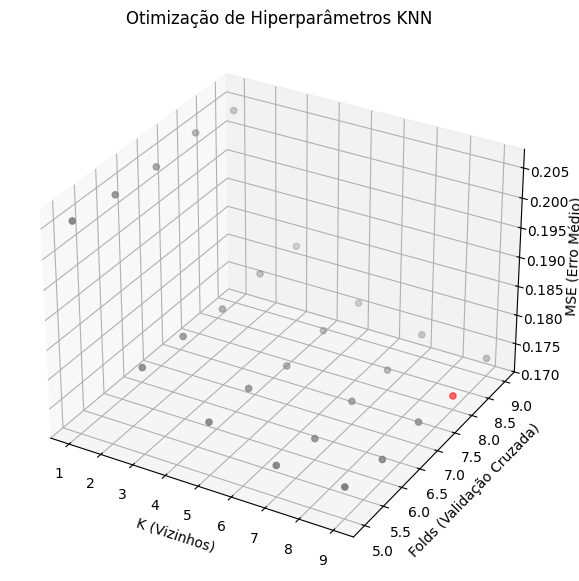

In [6]:
# =================================================================
# 6. Visualização
# =================================================================
print("\n--- RESULTADOS ---")
print(f"O número ideal de vizinhos (k) é: {df_knn.loc[index_opt, 'k_list']}")
print(f"O número ideal de folds (f) é: {df_knn.loc[index_opt, 'fold_list']}")
print(f"Menor Erro de Classificação: {optimal_k_val:.4f}")

plt.rcParams['figure.figsize'] = (11, 7)
ax = plt.axes(projection='3d')

# Cores para destacar o ponto ótimo
colors = ['red' if i == index_opt else 'grey' for i in range(len(df_knn))]
ax.scatter3D(df_knn['k_list'], df_knn['fold_list'], df_knn['MSE'], c=colors)

ax.set_title('Otimização de Hiperparâmetros KNN')
ax.set_xlabel('K (Vizinhos)')
ax.set_ylabel('Folds (Validação Cruzada)')
ax.set_zlabel('MSE (Erro Médio)')
plt.show()

In [7]:
# =================================================================
# 7. Métricas do Modelo
# =================================================================
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Treinar o modelo final com o melhor K encontrado
# (Utilizando X e y de todo o dataset mesmo)
best_k = int(df_knn.loc[index_opt, 'k_list'])

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X, y)

# Realizar as predições
y_pred = knn_final.predict(X)

# Gerar a Matriz de Confusão
cm = confusion_matrix(y, y_pred)

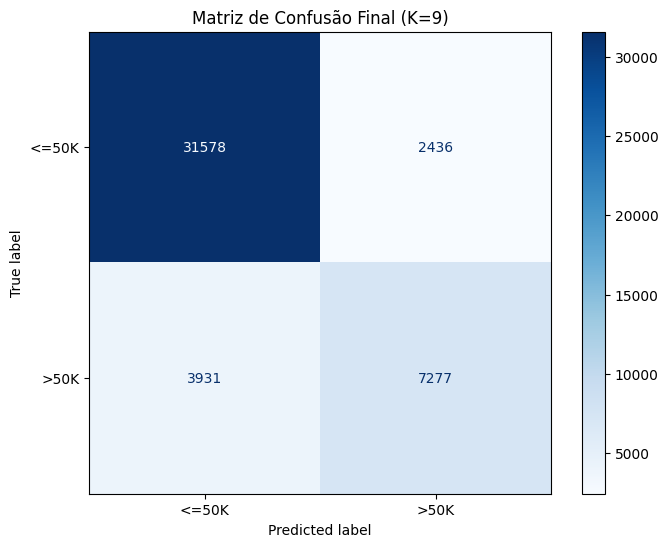


RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91     34014
        >50K       0.75      0.65      0.70     11208

    accuracy                           0.86     45222
   macro avg       0.82      0.79      0.80     45222
weighted avg       0.85      0.86      0.86     45222



In [8]:
# =================================================================
# 8. Visualização Gráfica da Matriz de Confusão
# =================================================================
target_le = preprocessing.LabelEncoder()
target_le.fit(df['class']) # 'df' ainda contém os dados originais processados

# Visualização Gráfica
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)

# Plotar
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f'Matriz de Confusão Final (K={best_k})')
plt.grid(False)
plt.show()

# Relatório de Classificação
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*60)
print(classification_report(y, y_pred, target_names=target_le.classes_))
print("="*60)